In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
from pathlib import Path

s2p_dir = Path("/Volumes/rkc_ramirezlab/Home/suthardr/Projects/2photon_menace/Astro2P_Pilot#5_2025Oct/PreProcess/gcamp/10072025/932L/suite2p/plane0/")

# spks is neurons by time
spks = np.load(s2p_dir / "spks.npy").astype("float32")
iscell = np.load(s2p_dir / "iscell.npy", allow_pickle=True)


In [36]:
# Create a boolean mask for true cells
cell_mask = iscell[:, 0].astype(bool)

# Filter data
F_spks = spks[cell_mask, :]

print(f"Original ROIs: {spks.shape[0]}, Filtered cells: {F_spks.shape[0]}")

Original ROIs: 841, Filtered cells: 33


In [32]:
from scipy.stats import zscore

F_spksZ = zscore(F_spks, axis=1)

2025-11-01 22:13:01,343 [INFO] normalizing data across axis=1
2025-11-01 22:13:01,347 [INFO] projecting out mean along axis=0
2025-11-01 22:13:01,350 [INFO] data normalized, 0.01sec
2025-11-01 22:13:01,351 [INFO] sorting activity: 33 valid samples by 27600 timepoints
2025-11-01 22:13:01,449 [INFO] n_PCs = 33 computed, 0.11sec


/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/rastermap.py:357: UserWarning: data has <= 50 samples, 

                                going to skip clustering and sort samples
  warnings.warn("""data has <= 50 samples, \n


2025-11-01 22:13:01,799 [INFO] clusters sorted, time 0.46sec
2025-11-01 22:13:01,811 [INFO] clusters upsampled, time 0.47sec
2025-11-01 22:13:01,817 [INFO] rastermap complete, time 0.47sec


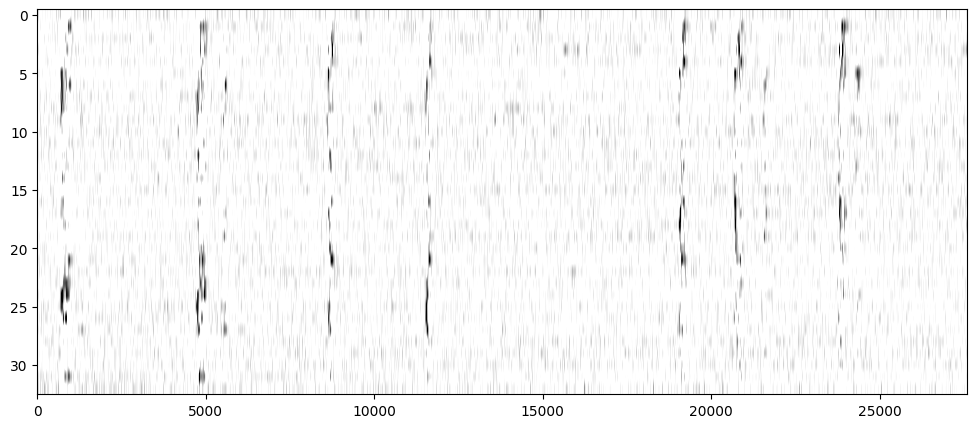

In [49]:
# fit rastermap
model = Rastermap(n_PCs=200, n_clusters=33,
                  locality=1, time_lag_window=15).fit(F_spks)
y = model.embedding # neurons x 1
isort = model.isort

# visualize binning over neurons
X_embedding = model.X_embedding

# plot
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)
ax.imshow(X_embedding, vmin=0, vmax=1.5, cmap="gray_r", aspect="auto")